# Chapter 6: Advanced Logistic Regression and Extensions

This notebook reproduces the code and summarizes the concepts from **scikit-learn Cookbook (3rd Edition)**, published by Packt, Chapter 6. The explanations below have been rewritten in my own words rather than copied verbatim from the book.

Although most people who have used regression before tend to associate it with predicting continuous outcomes, regression is actually quite versatile and can also handle qualitative, discrete outcomes — the kind found in classification problems. In fact, it is arguable that many traditional ML problems in business are classification problems rather than regression ones.

**In this chapter, we cover the following recipes:**
- Overview of logistic regression
- Multiclass classification techniques
- Regularization in logistic regression
- Multilabel classification concepts
- Model evaluation metrics


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer, load_iris, make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_curve, auc
)

%matplotlib inline


## Overview of Logistic Regression

Unlike linear regression, which predicts continuous outcomes, logistic regression predicts the **probability** that a given input belongs to a particular class. This is achieved by applying the **logistic function** (also known as the **sigmoid function**) to a linear combination of the input features:

$$P(Y=1 \mid X) = \frac{1}{1+e^{-(\beta_0+\beta_1 X_1+\dots+\beta_n X_n)}}$$

The sigmoid squashes any real-valued input into the range $(0, 1)$. The decision rule is simple: if $P(Y=1\mid X) > 0.5$, predict class $1$; otherwise predict class $0$.

Model parameters ($\beta$) are estimated using **maximum likelihood estimation (MLE)**, which is mathematically equivalent to minimizing the **binary cross-entropy loss**.

### The log-odds connection

The *log-odds* (or **logit**) of an event is the natural logarithm of its odds — the ratio of the probability an event happens to the probability it does not. Logistic regression is actually a *linear* model in log-odds space:

$$\log \frac{P(Y=1)}{P(Y=0)} = \beta_0+\beta_1 X_1+\dots+\beta_n X_n$$

This log-odds transform converts a bounded probability scale $(0,1)$ into an unbounded, linear scale — which is exactly what makes logistic regression a *linear* classifier despite producing non-linear (S-shaped) probability curves.

The example below uses the built-in *Breast Cancer* dataset for binary classification (malignant vs. benign).

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(
    df[data.feature_names], df['target'], test_size=0.2, random_state=2024
)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")


Accuracy: 0.947


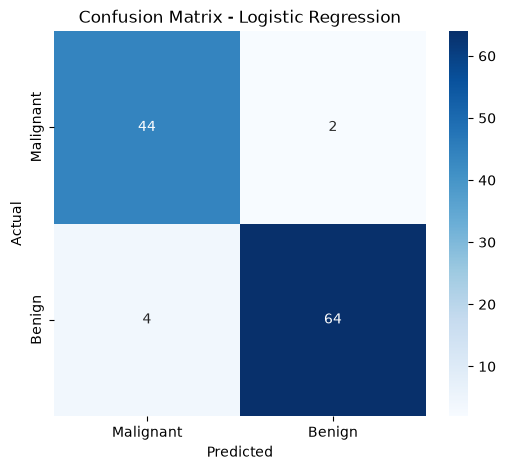

In [3]:
class_names = ['Malignant', 'Benign']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


In [4]:
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
pd.DataFrame(report).transpose().round(3)


,precision,recall,f1-score,support
Malignant,0.917,0.957,0.936,46.000
Benign,0.970,0.941,0.955,68.000
accuracy,0.947,0.947,0.947,0.947
macro avg,0.943,0.949,0.946,114.000
weighted avg,0.948,0.947,0.948,114.000


With $569$ samples and $30$ features, a plain logistic regression model already reaches **$94.7\%$ accuracy** out of the box — a strong baseline for binary classification.

**Note:** accuracy alone is rarely the best metric, especially for a medical use case like this one. A low recall on the *malignant* class means sick patients are being missed, which is far more costly than a false alarm on the benign class — this is why precision and recall deserve equal attention alongside accuracy.

## Multiclass Classification Techniques

Real-world outcomes are not always binary (0 vs. 1, day vs. night). Logistic regression can be extended to handle more than two classes using two main strategies:

- **One-vs-Rest (OvR)**: train one separate binary classifier per class (that class vs. all others), then at prediction time pick the classifier with the highest confidence score.
- **Multinomial (softmax) regression**: directly model the probabilities of all $C$ classes simultaneously using the **softmax function**:

$$P(Y=c \mid \mathbf{x}) = \frac{e^{\mathbf{w}_c^T\mathbf{x}+b_c}}{\sum_{k=1}^{C}e^{\mathbf{w}_k^T\mathbf{x}+b_k}}$$

Softmax guarantees the probabilities across all classes sum to $1$, making it the natural generalization of the sigmoid to multiple classes. When $C=2$, softmax reduces exactly to the sigmoid function.

**Compatibility note:** in recent scikit-learn versions, the `multi_class` parameter has been removed from `LogisticRegression`, and the `liblinear` solver no longer supports multiclass problems directly. The multinomial approach is now applied by default whenever there are $\geq 3$ classes. To still run an explicit OvR scheme, the classifier needs to be wrapped with `OneVsRestClassifier`.

The example below uses the *Iris* dataset (3 classes).

In [5]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
df_iris = pd.DataFrame(X, columns=feature_names)
df_iris['target'] = y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# One-vs-Rest, wrapped explicitly for compatibility with recent scikit-learn versions
ovr_model = OneVsRestClassifier(LogisticRegression(solver='liblinear', max_iter=1000))
ovr_model.fit(X_train, y_train)
y_pred_ovr = ovr_model.predict(X_test)

# Multinomial (lbfgs solver applies softmax automatically for >=3 classes)
multinomial_model = LogisticRegression(solver='lbfgs', max_iter=1000)
multinomial_model.fit(X_train, y_train)
y_pred_multi = multinomial_model.predict(X_test)

print("One-vs-Rest Accuracy  :", round(accuracy_score(y_test, y_pred_ovr), 4))
print("Multinomial Accuracy  :", round(accuracy_score(y_test, y_pred_multi), 4))


One-vs-Rest Accuracy  : 0.9556
Multinomial Accuracy  : 0.9333


In [6]:
pd.DataFrame(classification_report(y_test, y_pred_ovr, target_names=iris.target_names, output_dict=True)).transpose().round(3)


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,18.000
versicolor,0.917,0.917,0.917,12.000
virginica,0.933,0.933,0.933,15.000
accuracy,0.956,0.956,0.956,0.956
macro avg,0.950,0.950,0.950,45.000
weighted avg,0.956,0.956,0.956,45.000


On this run, OvR reached **$95.6\%$** accuracy and multinomial **$93.3\%$** — both are strong and broadly comparable, confirming that for a well-separated dataset like Iris, the choice between the two strategies matters less than it would on harder, more ambiguous data.

The fundamental difference: OvR trains independent binary classifiers per class and picks the most confident one, while multinomial estimates all class probabilities jointly via softmax — a better fit when the classes are known to be mutually exclusive.

A pairplot helps visualize how separable the classes are based on the raw features.

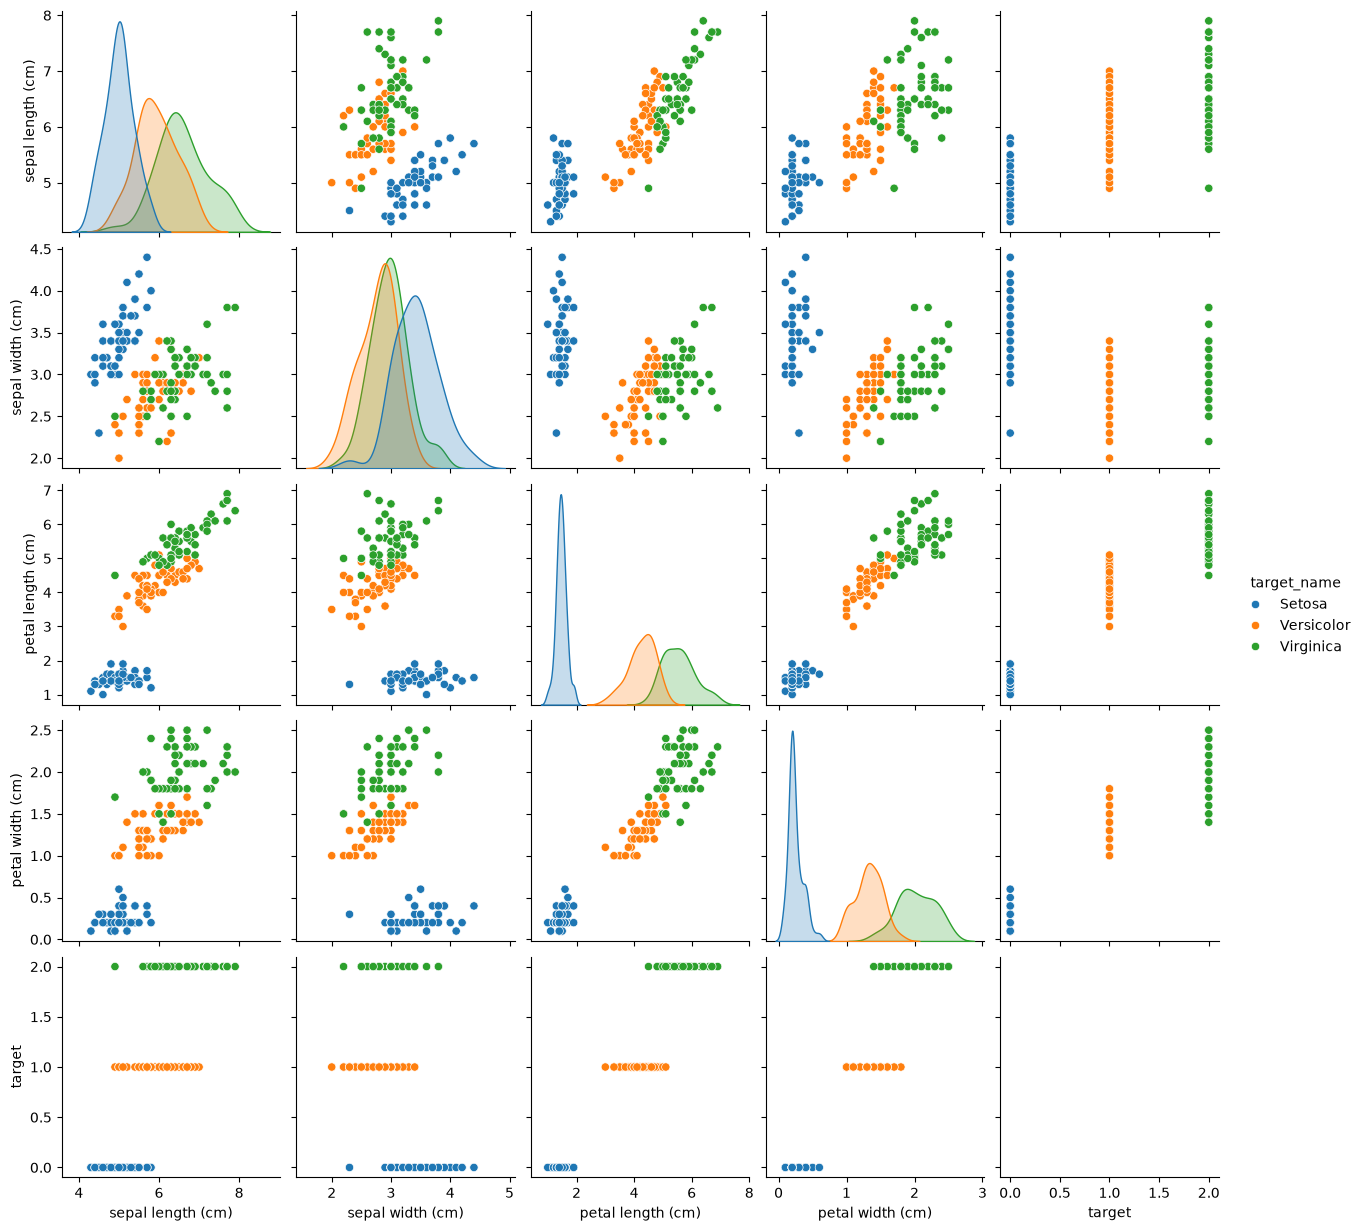

In [7]:
target_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
df_iris['target_name'] = df_iris['target'].map(target_names)
sns.pairplot(df_iris, hue='target_name', diag_kind='kde')
plt.show()


The *petal length* and *petal width* columns show sharply separated distributions across species — these two features are clearly the most informative for distinguishing Iris classes, which is consistent with the near-perfect accuracy both models achieve.

### Practical considerations
- **Solver choice**: `liblinear` is a good fit for OvR, while `lbfgs` or `newton-cg` are standard choices for multinomial regression.
- **Regularization** remains important for multiclass models, exactly as in the binary case.
- **Feature scaling** generally improves logistic regression performance regardless of the strategy used.

## Regularization in Logistic Regression

Regularization adds a penalty term to the loss function that discourages the model from assigning overly large coefficients — this helps prevent overfitting, especially with high-dimensional data.

- **Ridge ($\ell_2$)**: penalty proportional to the squared magnitude of the coefficients — shrinks coefficients toward zero but rarely sets them exactly to zero.
- **Lasso ($\ell_1$)**: penalty proportional to the absolute value of the coefficients — can drive some coefficients to exactly zero, effectively performing automatic feature selection.

$$\text{Ridge: } \; \min_\beta \; \text{CE}(\beta) + \lambda \sum_j \beta_j^2 \qquad \text{Lasso: } \; \min_\beta \; \text{CE}(\beta) + \lambda \sum_j |\beta_j|$$

The `C` parameter in scikit-learn controls the *inverse* of regularization strength — smaller `C` means stronger regularization.

In [8]:
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ridge_model = LogisticRegression(penalty='l2', solver='liblinear', C=0.1)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

n_nonzero = np.sum(lasso_model.coef_[0] != 0)

print("Ridge (L2) Accuracy:", round(accuracy_score(y_test, y_pred_ridge), 4))
print("Lasso (L1) Accuracy:", round(accuracy_score(y_test, y_pred_lasso), 4))
print(f"Lasso kept {n_nonzero} out of {X.shape[1]} features non-zero")


Ridge (L2) Accuracy: 0.9825
Lasso (L1) Accuracy: 0.9649
Lasso kept 7 out of 30 features non-zero


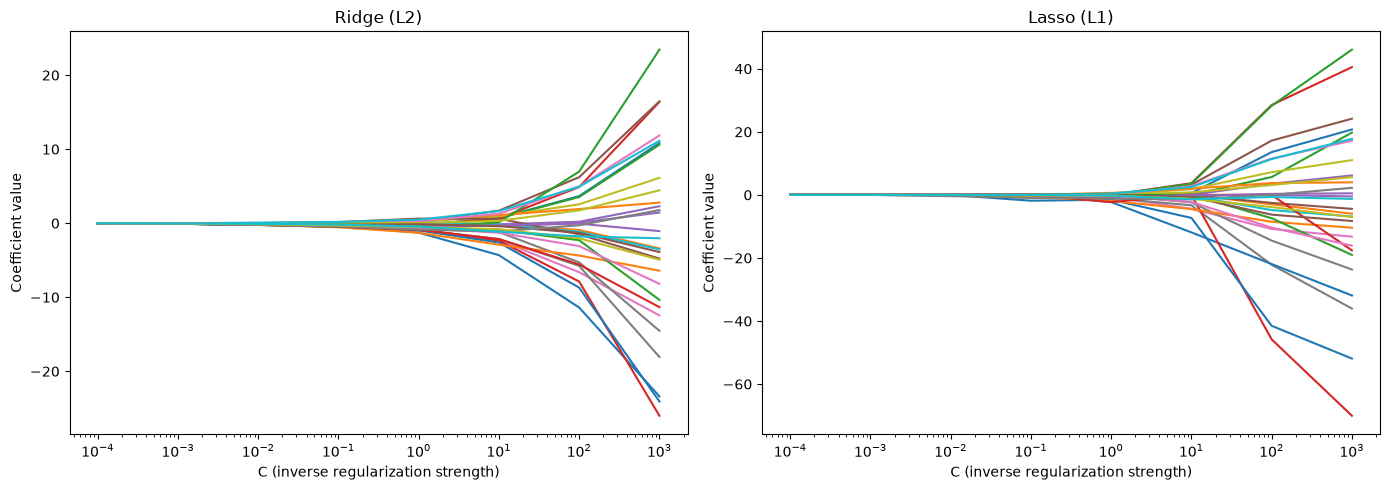

In [9]:
C_values = np.array([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
coefs_ridge, coefs_lasso = [], []

for C in C_values:
    rm = LogisticRegression(penalty='l2', solver='liblinear', C=C).fit(X_train, y_train)
    coefs_ridge.append(rm.coef_[0])
    lm = LogisticRegression(penalty='l1', solver='liblinear', C=C).fit(X_train, y_train)
    coefs_lasso.append(lm.coef_[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i in range(X.shape[1]):
    axes[0].plot(C_values, [c[i] for c in coefs_ridge])
    axes[1].plot(C_values, [c[i] for c in coefs_lasso])
for ax, title in zip(axes, ['Ridge (L2)', 'Lasso (L1)']):
    ax.set_xscale('log')
    ax.set_xlabel('C (inverse regularization strength)')
    ax.set_ylabel('Coefficient value')
    ax.set_title(title)
plt.tight_layout()
plt.show()


Ridge reached **$98.2\%$** accuracy while keeping all $30$ features active, and Lasso reached **$96.5\%$** while zeroing out several coefficients — a direct demonstration of automatic feature selection in action, at a modest cost in accuracy.

The coefficient paths above show the qualitative difference clearly: Ridge coefficients shrink smoothly toward zero as `C` decreases, while Lasso coefficients tend to snap to exactly zero and stay there — this sparsity is exactly what makes Lasso useful for feature selection.

**Other practical notes**: `liblinear` works well for small datasets with $\ell_1$/$\ell_2$ penalties, while `saga` scales better to large datasets. Feature scaling (e.g. with `StandardScaler`) is essential before regularization, since the penalty is sensitive to the magnitude of each feature.

## Multilabel Classification Concepts

Unlike multiclass (one observation → exactly one class out of several), **multilabel** classification allows a single observation to carry **more than one label at once** — for example, a news article could belong to both "sports" and "politics" simultaneously. This is common in text categorization, image tagging, and bioinformatics.

The simplest approach is **binary relevance**: train one independent binary classifier per label (essentially an OvR scheme), then combine their individual predictions.

In [10]:
X, y = make_multilabel_classification(
    n_samples=1000, n_features=20, n_classes=5, n_labels=2, random_state=2024
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

models = []
y_pred_all = []

for i in range(y_train.shape[1]):
    model = LogisticRegression(solver='liblinear')
    model.fit(X_train, y_train[:, i])
    models.append(model)
    y_pred_all.append(model.predict(X_test))

y_pred = np.array(y_pred_all).T
accuracy = accuracy_score(y_test, y_pred)
print(f"Exact-match accuracy (all labels correct): {accuracy:.3f}")


Exact-match accuracy (all labels correct): 0.340


In [11]:
report = pd.DataFrame(
    classification_report(y_test, y_pred, zero_division=1, output_dict=True)
).transpose()
report.round(3)


,precision,recall,f1-score,support
0,0.808,0.813,0.811,166.0
1,0.801,0.845,0.823,181.0
2,0.674,0.333,0.446,93.0
3,0.750,0.176,0.286,34.0
4,0.575,0.477,0.522,88.0
micro avg,0.757,0.653,0.701,562.0
macro avg,0.722,0.529,0.577,562.0
weighted avg,0.744,0.653,0.677,562.0
samples avg,0.787,0.782,0.680,562.0


The exact-match accuracy (all 5 labels correct simultaneously) sits around **$0.34$** — much lower than the per-label F1-scores suggest, which highlights why exact-match accuracy is a harsh metric for multilabel problems: getting even one label wrong out of five counts as a complete miss. Per-label F1-scores vary noticeably (roughly $0.29$ to $0.82$ in this run), reflecting the underlying label imbalance in the synthetic dataset.

**Shortcut:** scikit-learn also provides `MultiOutputClassifier()`, which wraps a single base classifier (e.g. `LogisticRegression()`) and fits it to every target automatically — functionally equivalent to the manual loop above, with less boilerplate.

We can also inspect which labels tend to co-occur using a *label co-occurrence matrix*.

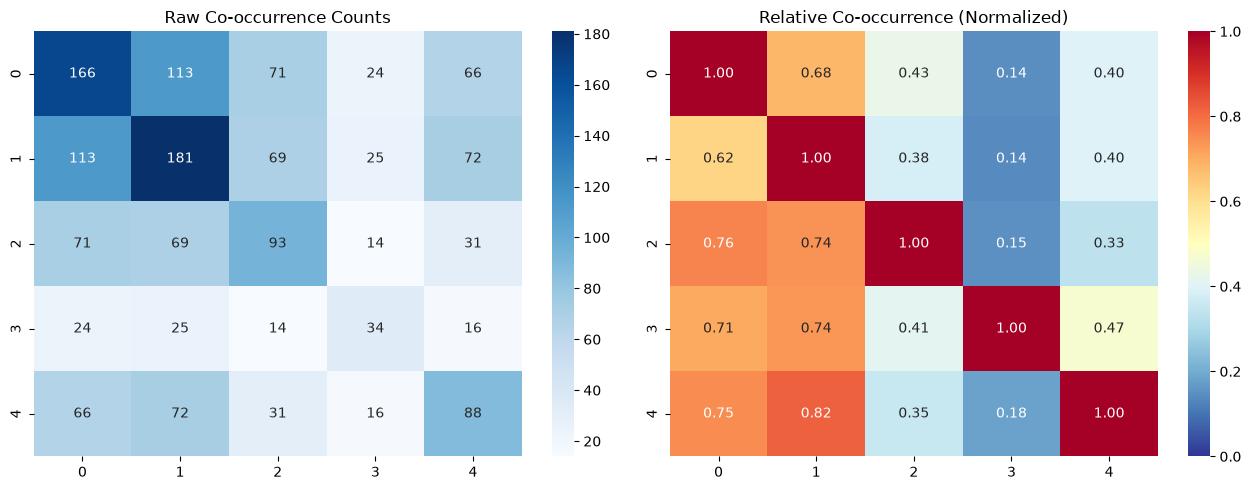

In [12]:
cooccurrence = y_test.T @ y_test
diag = np.diag(cooccurrence)
relative_cooccurrence = cooccurrence / diag[:, None]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Raw Co-occurrence Counts')
sns.heatmap(relative_cooccurrence, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax2, vmin=0, vmax=1)
ax2.set_title('Relative Co-occurrence (Normalized)')
plt.tight_layout()
plt.show()


Cells close to $1$ indicate that whenever label $i$ appears, label $j$ almost always appears too. Asymmetric patterns are especially interesting — label A might always accompany label B, while B can occur on its own without A.

Beyond binary relevance, other multilabel strategies include *classifier chains* (which explicitly model label dependencies) — each has different trade-offs depending on how correlated the labels actually are.

## Model Evaluation Metrics

Common metrics for evaluating classification models:

- **Accuracy**: overall proportion of correct predictions.
- **Precision**: of everything predicted positive, how much was actually positive.
- **Recall**: of everything actually positive, how much was correctly detected.
- **$F_1$-score**: harmonic mean of precision and recall, $F_1 = \frac{2 \cdot P \cdot R}{P+R}$.
- **ROC curve & AUC**: traces the trade-off between true positive rate and false positive rate across all thresholds; AUC condenses this into one summary score.

In [13]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")


Accuracy : 0.936
Precision: 0.943
Recall   : 0.952
F1 Score : 0.947


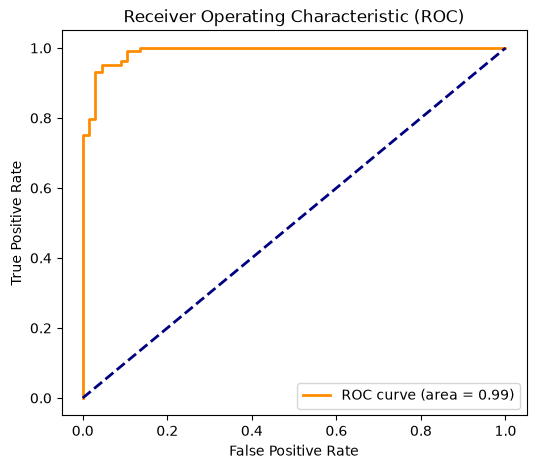

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()


The accuracy ($93.6\%$) looks solid, but the ROC curve tells an even stronger story: the AUC comes out near $0.99$, meaning the model is almost perfectly able to rank malignant cases above benign ones across every possible decision threshold — a case where AUC paints a more complete picture than accuracy alone.

**When to use which metric in practice:**
- **Balanced datasets, equal error costs** → Accuracy or $F_1$ are fine.
- **Imbalanced datasets** → Prefer precision-recall curves and $F_1$ (ROC can look overly optimistic when negatives dominate).
- **Ranking / scoring tasks** → Use AUC — it checks whether probability scores are *ordered correctly*, independent of any single threshold.
- **Medical screening** → Prioritize recall (sensitivity) — missing a real case is worse than a false alarm.
- **Spam filtering** → Prioritize precision — blocking a legitimate email is worse than letting one spam message through.

---
## Chapter Summary

- Logistic regression models class probability through the sigmoid function, with parameters estimated via MLE (equivalent to minimizing cross-entropy loss). On the Breast Cancer dataset it reaches **$94.7\%$** accuracy out of the box.
- For more than two classes, logistic regression extends via **One-vs-Rest** or **Multinomial (softmax)** strategies — both performed competitively on Iris ($95.6\%$ vs. $93.3\%$ accuracy respectively).
- **Regularization** ($\ell_1$/$\ell_2$) controls overfitting through the `C` parameter. Ridge kept all $30$ features and reached $98.2\%$ accuracy, while Lasso dropped several coefficients to zero (automatic feature selection) and still reached $96.5\%$.
- **Multilabel classification** lets one observation carry several labels at once, typically handled via binary relevance (one classifier per label); exact-match accuracy is a notably strict metric compared to per-label scores.
- Model evaluation should go beyond accuracy — precision, recall, $F_1$, and ROC-AUC together give a much fuller picture of performance, which matters most on imbalanced or high-stakes classification tasks.